In [5]:

import torch
import os

MODEL_PATH = "best_emotion_model_v3.pt"

# Find model file
model_file = MODEL_PATH
if not os.path.exists(model_file):
    for root, _, files in os.walk('.'):
        if os.path.basename(MODEL_PATH) in files:
            model_file = os.path.join(root, os.path.basename(MODEL_PATH))
            break

if not os.path.exists(model_file):
    print(f" Model file not found: {MODEL_PATH}")
    print("   Please run the training notebook first!")
else:
    print(f" Model file found: {os.path.abspath(model_file)}")
    print(f"   Size: {os.path.getsize(model_file) / 1024 / 1024:.2f} MB")
    
    # Load and inspect checkpoint
    try:
        checkpoint = torch.load(model_file, map_location='cpu', weights_only=False)
        
        print("\n Checkpoint Contents:")
        if isinstance(checkpoint, dict):
            print(f"   Keys: {list(checkpoint.keys())}")
            
            if 'val_acc' in checkpoint:
                print(f"\n Model Performance:")
                print(f"   Validation Accuracy: {checkpoint['val_acc']:.4f} ({checkpoint['val_acc']*100:.2f}%)")
                print(f"   Validation F1: {checkpoint['val_f1']:.4f}")
                print(f"   Trained for {checkpoint.get('epoch', 'unknown')} epochs")
            
            if 'config' in checkpoint:
                print(f"\n Training Configuration:")
                config = checkpoint['config']
                print(f"   Batch size: {config.get('batch_size')}")
                print(f"   Image size: {config.get('img_size')}")
                print(f"   Sequence length: {config.get('sequence_len')}")
                print(f"   Learning rate: {config.get('lr')}")
                print(f"   Total sequences: {config.get('num_sequences'):,}")
            
            if 'model_state' in checkpoint:
                state_dict = checkpoint['model_state']
                print(f"\n Model Architecture Info:")
                print(f"   Total parameters: {len(state_dict)} layers")
                
                # Check for key layers to identify architecture
                has_feature_projection = any('feature_projection' in k for k in state_dict.keys())
                has_attention = any('attention' in k for k in state_dict.keys())
                has_classifier = any('classifier' in k for k in state_dict.keys())
                
                print(f"   Has feature_projection: {has_feature_projection}")
                print(f"   Has attention: {has_attention}")
                print(f"   Has classifier: {has_classifier}")
                
                # Identify backbone
                if any('feature_extractor.0.conv1' in k for k in state_dict.keys()):
                    first_conv = state_dict.get('feature_extractor.0.conv1.weight')
                    if first_conv is not None:
                        print(f"   Backbone detected: ResNet (first conv: {first_conv.shape})")
        
        print("\n Model saved successfully and ready to use!")
        
    except Exception as e:
        print(f"\n Error loading checkpoint: {e}")

 Model file found: d:\PROJECTS\HealthResearch\Healt_Research_ML_Models\backend\app\models\best_emotion_model_v3.pt
   Size: 161.19 MB

 Checkpoint Contents:
   Keys: ['epoch', 'model_state', 'optimizer_state', 'scheduler_state', 'val_acc', 'val_f1', 'val_loss', 'train_acc', 'train_f1', 'classes', 'history', 'config']

 Model Performance:
   Validation Accuracy: 0.9544 (95.44%)
   Validation F1: 0.9543
   Trained for 48 epochs

 Training Configuration:
   Batch size: 32
   Image size: 128
   Sequence length: 8
   Learning rate: 0.0001
   Total sequences: 2,926

 Model Architecture Info:
   Total parameters: 144 layers
   Has feature_projection: True
   Has attention: True
   Has classifier: True

 Model saved successfully and ready to use!


 Model architecture loaded - EXACT MATCH with training!
 Loading model from: d:\PROJECTS\HealthResearch\Healt_Research_ML_Models\backend\app\models\best_emotion_model_v3.pt
 Loaded checkpoint from epoch 48
   Val Accuracy: 0.9544
   Val F1: 0.9543
 Model loaded successfully on cpu
   Architecture: LightweightCNN_LSTM_V3 (ResNet18)
   Parameters: 14,071,112

🎥 LIVE EMOTION DETECTION - FIXED & OPTIMIZED
 Model matches training configuration:
   - Architecture: LightweightCNN_LSTM_V3
   - Image size: 128x128
   - Sequence length: 8 frames
   - Prediction rate: 1.0 per second
 Loaded checkpoint from epoch 48
   Val Accuracy: 0.9544
   Val F1: 0.9543
 Model loaded successfully on cpu
   Architecture: LightweightCNN_LSTM_V3 (ResNet18)
   Parameters: 14,071,112

🎥 LIVE EMOTION DETECTION - FIXED & OPTIMIZED
 Model matches training configuration:
   - Architecture: LightweightCNN_LSTM_V3
   - Image size: 128x128
   - Sequence length: 8 frames
   - Prediction rate: 1.0 per second

Capture starte

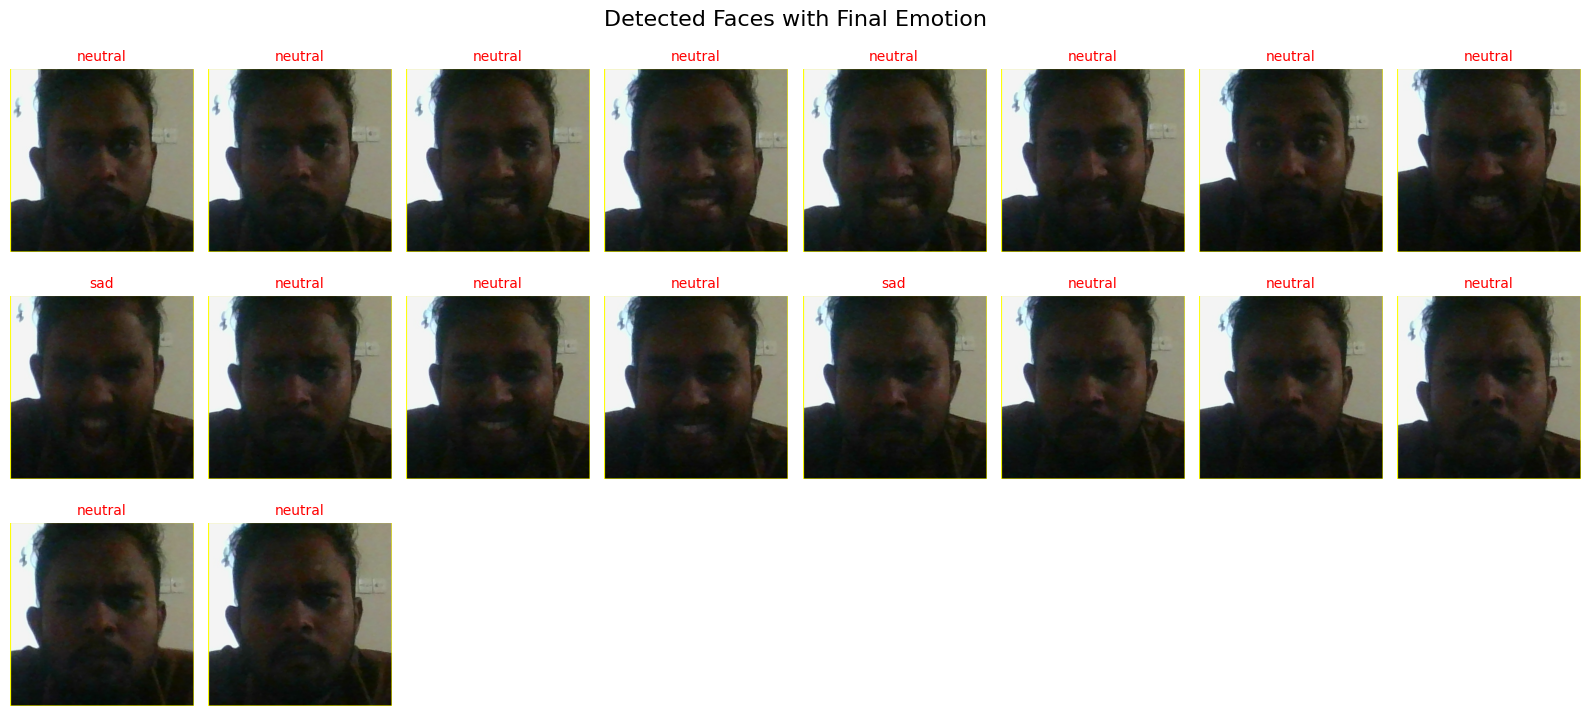

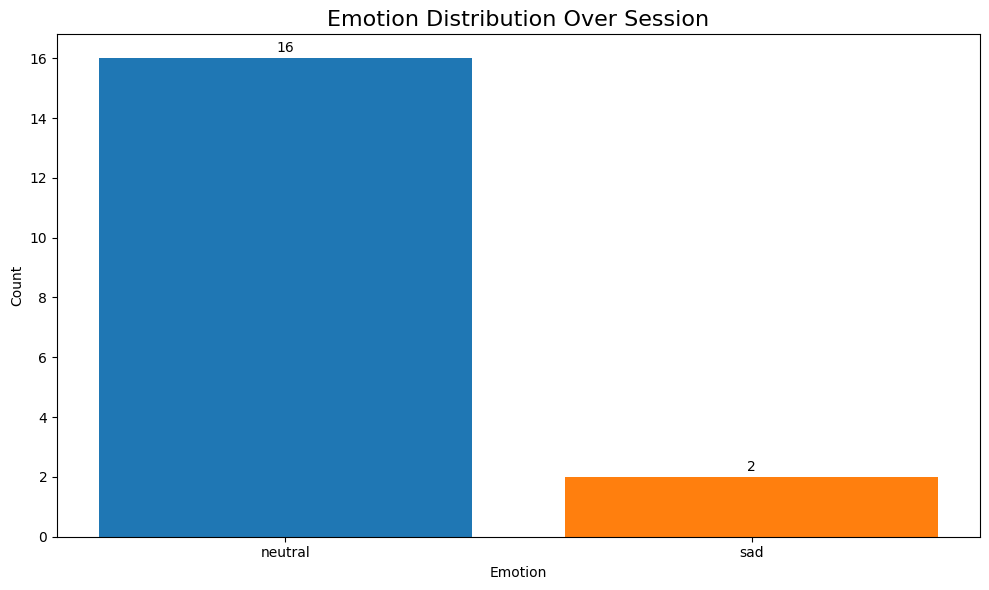

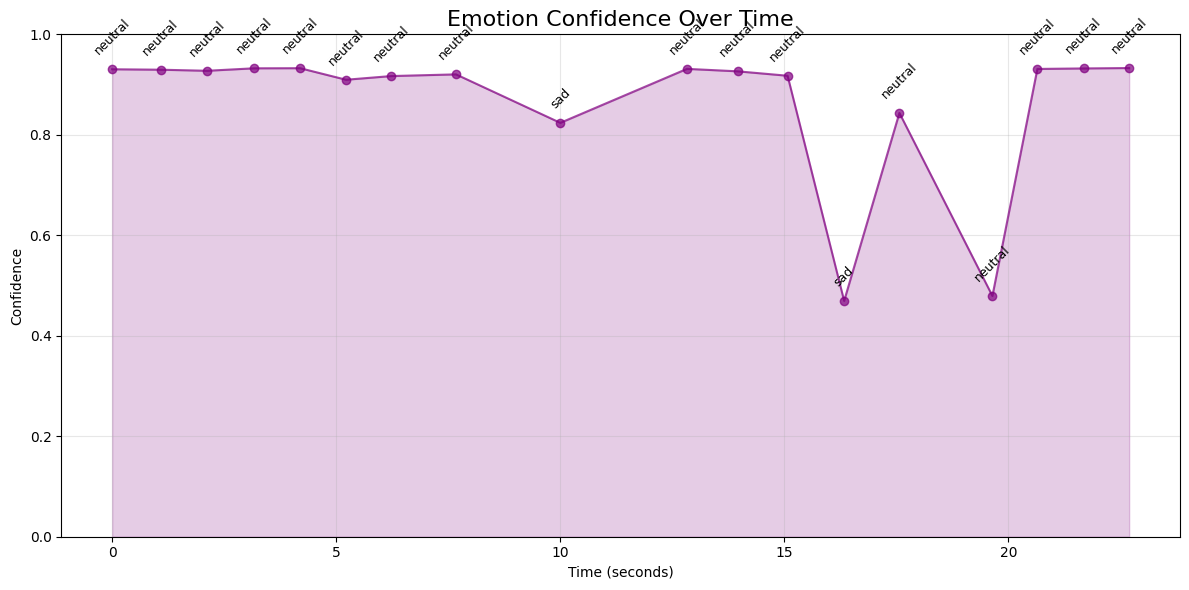

In [6]:
# live_emotion_detection_with_analysis.py
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import time
import numpy as np
import os
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import threading

# ==========================
# CONFIG - MUST MATCH TRAINING EXACTLY!
# ==========================
MODEL_PATH = os.path.join("models", "best_emotion_model_v3.pt")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 128  #  CRITICAL: Must match training (was 224)
EMOTION_CLASSES = ['angry', 'sad', 'happy', 'fearful', 'disgusted', 'surprised', 'neutral']

# Camera
CAM_WIDTH = 1280
CAM_HEIGHT = 720
WINDOW_NAME = "Live Emotion Detection - FIXED (Press 'q' when done)"
FACE_PADDING = 0.25

# Prediction: 1 prediction per second
PREDICTION_INTERVAL = 1.0  # seconds
SEQUENCE_LENGTH = 8  #  CRITICAL: Must match training (was 6)

# Data storage
emotion_history = []        # List of (timestamp, emotion, confidence, face_image)
face_images_grid = []       # Store face crops for final grid
last_prediction_time = 0.0

# ==========================
# FACE DETECTOR & TRANSFORM
# ==========================
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================
# MODEL DEFINITION - MUST MATCH TRAINING EXACTLY!
# ==========================
class LightweightCNN_LSTM_V3(nn.Module):
    """
     EXACT SAME ARCHITECTURE AS TRAINING!
    - ResNet18 backbone (NOT ResNet34/50)
    - 256 hidden size, 2 layers
    - Simple attention mechanism
    - NO extra projection layers
    """
    def __init__(self, num_classes, hidden_size=256, num_layers=2, dropout=0.4):
        super(LightweightCNN_LSTM_V3, self).__init__()
        
        # ResNet18 backbone - EXACT MATCH
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
        feature_size = 512  # ResNet18 output size
        
        # Lightweight feature projection
        self.feature_projection = nn.Sequential(
            nn.Linear(feature_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)
        )
        
        # Lightweight Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Simple attention mechanism
        self.attention = nn.Linear(hidden_size * 2, 1)
        
        # Lightweight classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_size, num_classes)
        )
    
    def forward(self, x):  # x: [B, T, C, H, W]
        B, T, C, H, W = x.size()
        
        # Extract features from each frame
        feats = []
        for t in range(T):
            f = self.feature_extractor(x[:, t, :, :, :])
            f = f.squeeze(-1).squeeze(-1)  # [B, 512]
            feats.append(f)
        feats = torch.stack(feats, dim=1)  # [B, T, 512]
        
        # Project features
        feats_reshaped = feats.reshape(B * T, -1)
        feats_projected = self.feature_projection(feats_reshaped)
        feats = feats_projected.reshape(B, T, -1)  # [B, T, hidden_size]
        
        # LSTM for temporal modeling
        lstm_out, _ = self.lstm(feats)  # [B, T, hidden_size*2]
        
        # Apply attention mechanism
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)  # [B, T, 1]
        
        # Weighted sum of LSTM outputs
        context = torch.sum(lstm_out * attn_weights, dim=1)  # [B, hidden_size*2]
        
        # Classification
        out = self.classifier(context)
        return out

print(" Model architecture loaded - EXACT MATCH with training!")

# ==========================
# LOAD MODEL - EXACT MATCH WITH TRAINING
# ==========================
model_file = MODEL_PATH
if not os.path.exists(model_file):
    for root, _, files in os.walk('.'):
        if os.path.basename(MODEL_PATH) in files:
            model_file = os.path.join(root, os.path.basename(MODEL_PATH))
            break
    else:
        raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

print(f" Loading model from: {os.path.abspath(model_file)}")

# Create model with EXACT same parameters as training
model = LightweightCNN_LSTM_V3(
    num_classes=len(EMOTION_CLASSES),
    hidden_size=256,
    num_layers=2,
    dropout=0.4
)

# Load checkpoint
try:
    state = torch.load(model_file, map_location=DEVICE, weights_only=False)
except:
    try:
        with torch.serialization.safe_globals([np.dtype]):
            state = torch.load(model_file, map_location=DEVICE)
    except:
        state = torch.load(model_file, map_location=DEVICE)

# Extract state dict
if isinstance(state, dict):
    if 'model_state' in state:
        state_dict = state['model_state']
        print(f" Loaded checkpoint from epoch {state.get('epoch', 'unknown')}")
        print(f"   Val Accuracy: {state.get('val_acc', 0):.4f}")
        print(f"   Val F1: {state.get('val_f1', 0):.4f}")
    elif 'state_dict' in state:
        state_dict = state['state_dict']
    else:
        state_dict = state
    
    # Remove 'module.' prefix if present
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    
    # Load weights
    model.load_state_dict(state_dict, strict=True)
else:
    raise ValueError("Invalid checkpoint format")

model.to(DEVICE)
model.eval()
print(f" Model loaded successfully on {DEVICE}")
print(f"   Architecture: LightweightCNN_LSTM_V3 (ResNet18)")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Frame buffer for temporal sequence (8 frames to match training)
frame_buffer = deque(maxlen=SEQUENCE_LENGTH)

print("\n" + "="*70)
print("🎥 LIVE EMOTION DETECTION - FIXED & OPTIMIZED")
print("="*70)
print(f" Model matches training configuration:")
print(f"   - Architecture: LightweightCNN_LSTM_V3")
print(f"   - Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"   - Sequence length: {SEQUENCE_LENGTH} frames")
print(f"   - Prediction rate: {PREDICTION_INTERVAL} per second")
print("="*70)

# ==========================
# VISUALIZATION FUNCTIONS (run after capture)
# ==========================
def show_results():
    if not emotion_history:
        print("No emotions detected during session.")
        return

    timestamps = [entry[0] for entry in emotion_history]
    emotions = [entry[1] for entry in emotion_history]
    confidences = [entry[2] for entry in emotion_history]
    face_crops = [entry[3] for entry in emotion_history]

    # Relative time from start
    start_time = timestamps[0]
    rel_times = [t - start_time for t in timestamps]

    # 1. Grid of Faces with Emotions
    cols = 8
    rows = (len(face_crops) + cols - 1) // cols
    plt.figure(figsize=(16, rows * 2.5))
    for i, (face, emo) in enumerate(zip(face_crops, emotions)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
        plt.title(emo, fontsize=10, color='red')
        plt.axis('off')
    plt.suptitle("Detected Faces with Final Emotion", fontsize=16)
    plt.tight_layout()
    plt.show()

    # 2. Bar Chart - Emotion Frequency
    emotion_counts = defaultdict(int)
    for emo in emotions:
        emotion_counts[emo] += 1

    plt.figure(figsize=(10, 6))
    bars = plt.bar(emotion_counts.keys(), emotion_counts.values(), color=plt.cm.tab10(range(7)))
    plt.title("Emotion Distribution Over Session", fontsize=16)
    plt.ylabel("Count")
    plt.xlabel("Emotion")
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.1, f'{int(height)}', 
                 ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

    # 3. Line Chart - Emotion Confidence Over Time
    plt.figure(figsize=(12, 6))
    plt.plot(rel_times, confidences, marker='o', linestyle='-', color='purple', alpha=0.7)
    plt.fill_between(rel_times, confidences, alpha=0.2, color='purple')
    plt.title("Emotion Confidence Over Time", fontsize=16)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Confidence")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)

    # Annotate emotion labels
    for t, emo, conf in zip(rel_times, emotions, confidences):
        plt.text(t, conf + 0.03, emo, fontsize=9, ha='center', rotation=45)

    plt.tight_layout()
    plt.show()

# ==========================
# MAIN CAPTURE LOOP
# ==========================
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, CAM_WIDTH)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, CAM_HEIGHT)
cv2.namedWindow(WINDOW_NAME, cv2.WINDOW_NORMAL)

print("\nCapture started — 1 emotion prediction per second")
print("Look at the camera and press 'q' when you're done.\n")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.1, 6, minSize=(80, 80))

        current_time = time.time()

        if len(faces) > 0:
            # Take largest face
            (x, y, w, h) = sorted(faces, key=lambda r: r[2]*r[3], reverse=True)[0]
            pad_x = int(w * FACE_PADDING)
            pad_y = int(h * FACE_PADDING)
            x1 = max(0, x - pad_x)
            y1 = max(0, y - pad_y)
            x2 = min(frame.shape[1], x + w + pad_x)
            y2 = min(frame.shape[0], y + h + pad_y)

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 255), 2)
            face_roi = frame[y1:y2, x1:x2]

            # Add to temporal buffer
            try:
                pil_img = Image.fromarray(cv2.cvtColor(face_roi, cv2.COLOR_BGR2RGB))
                tensor_img = transform(pil_img).to(DEVICE)
                frame_buffer.append(tensor_img)
            except:
                pass

            # Predict once per second when buffer is full
            if (len(frame_buffer) == SEQUENCE_LENGTH and 
                current_time - last_prediction_time >= PREDICTION_INTERVAL):

                with torch.no_grad():
                    clip = torch.stack(list(frame_buffer), dim=0).unsqueeze(0).to(DEVICE)
                    output = model(clip)
                    probs = F.softmax(output, dim=1).cpu()
                    conf, pred = torch.max(probs, 1)
                    emotion = EMOTION_CLASSES[pred.item()]
                    confidence = conf.item()

                    # Save result
                    emotion_history.append((current_time, emotion, confidence, face_roi.copy()))
                    face_images_grid.append(face_roi.copy())

                last_prediction_time = current_time

        # Minimal display: just the bounding box
        cv2.putText(frame, "Recording emotions... (q to finish)", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)
        cv2.putText(frame, f"Detected: {len(emotion_history)}", (10, 70),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)

        cv2.imshow(WINDOW_NAME, frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

finally:
    cap.release()
    cv2.destroyAllWindows()
    print(f"\nCapture finished. Total predictions: {len(emotion_history)}")

    if emotion_history:
        print("Generating visualizations...")
        show_results()
    else:
        print("No faces detected during session.")